In [19]:
import cv2
import torch
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from random import randint, choices

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

Using device: cuda


# EDA CCD

## Contents:

### Load labels

In [20]:
labels_path = r"D:\MAGISTERKA\anomaly_traffic_road\datasets\CarCrash\labels.txt"

with open(labels_path, 'r') as f:
    labels = list(map(lambda x: x.strip().split(','), f.readlines()))

vid_name = [label[0] for label in labels]
vid_labels = [label[1:51] for label in labels]
vid_labels = [[int(num.replace('[', '').replace(']', '')) for num in label_list] for label_list in vid_labels]
day_or_night = [label[-3] for label in labels]
weather = [label[-2] for label in labels]
self_ego = [label[-1] for label in labels]

vid_labels = np.array(vid_labels)
day_or_night = np.array(day_or_night)
weather = np.array(weather)
self_ego = np.array(self_ego)

In [21]:
len(vid_labels)

1500

### Class distribution

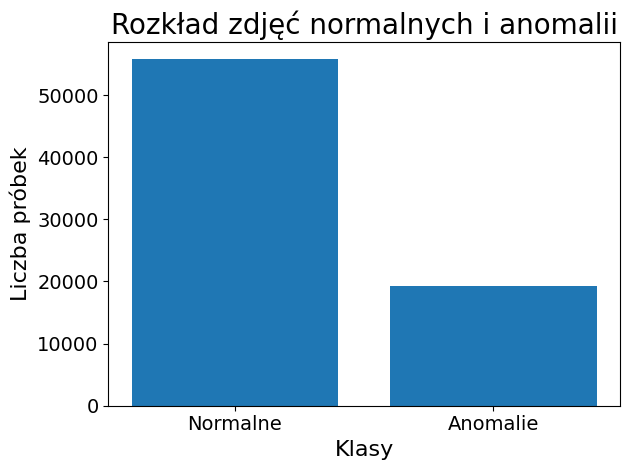

In [22]:
normal = 0
anomaly = 0

for l in vid_labels:
    normal += np.where(l == 0)[0].shape[0]
    anomaly += np.where(l == 1)[0].shape[0]

plt.bar(['Normalne', 'Anomalie'], [normal, anomaly])
plt.title('Rozkład zdjęć normalnych i anomalii', fontsize=20)
plt.xlabel('Klasy', fontsize=16)
plt.ylabel('Liczba próbek', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

### Night distribution

Unique values: ['Day' 'Night']


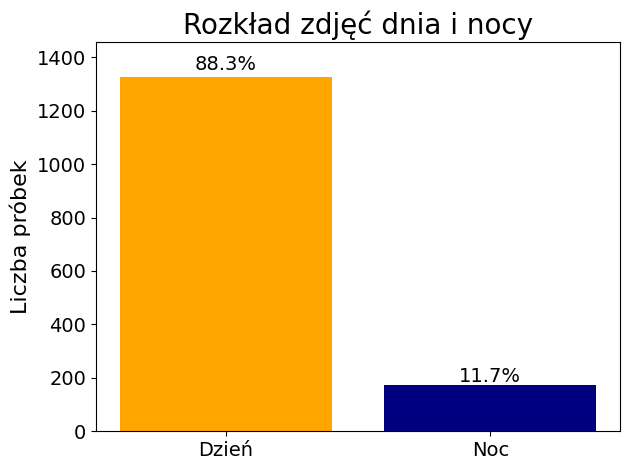

In [23]:
print(f"Unique values: {np.unique(day_or_night)}")
day_or_night = np.where(day_or_night == 'Day', 0, 1)

# Count occurrences
day_count = np.where(day_or_night == 0)[0].shape[0]
night_count = np.where(day_or_night == 1)[0].shape[0]
total = day_count + night_count

# Calculate percentages
day_percentage = (day_count / total) * 100
night_percentage = (night_count / total) * 100

plt.bar(['Dzień', 'Noc'], [np.where(day_or_night == 0)[0].shape[0], np.where(day_or_night == 1)[0].shape[0]], color=['#FFA500', '#000080'])

plt.text(0, day_count * 1.02, f'{day_percentage:.1f}%', ha='center', fontsize=14)
plt.text(1, night_count * 1.05, f'{night_percentage:.1f}%', ha='center', fontsize=14)

plt.title('Rozkład zdjęć dnia i nocy', fontsize=20)
plt.ylabel('Liczba próbek', fontsize=16)
plt.ylim(0, max(day_count, night_count) * 1.1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

### Weather distribution

Unique values: ['Normal' 'Rainy' 'Snowy']
[0 0 0 ... 2 2 0]


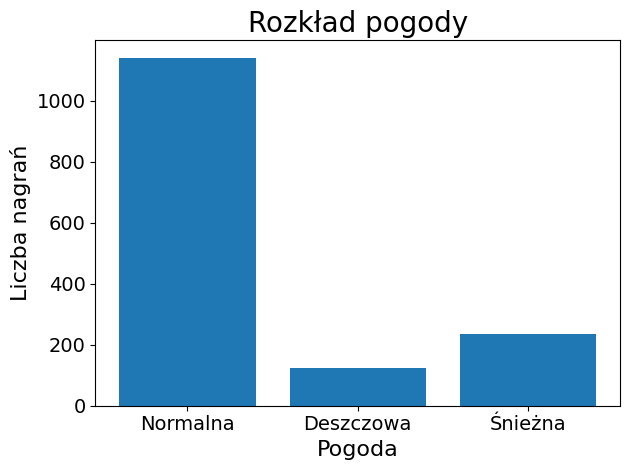

In [24]:
unique_values, labels = np.unique(weather, return_inverse=True)
print(f"Unique values: {unique_values}")
print(labels)

plt.bar(["Normalna", "Deszczowa", "Śnieżna"], [np.where(labels == i)[0].shape[0] for i in range(len(unique_values))])
plt.title('Rozkład pogody', fontsize=20)
plt.xlabel('Pogoda', fontsize=16)
plt.ylabel('Liczba nagrań', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

### Ego involved

Text(0.5, 1.0, 'Czy nagrywający brał udział w wypadku')

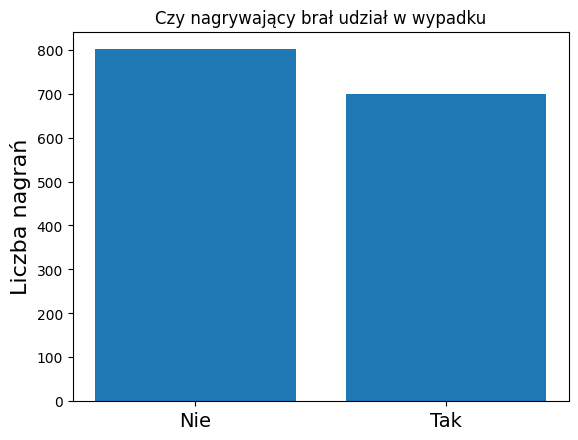

In [25]:
np.unique(self_ego)
self_ego = np.where(self_ego == 'Yes', 1, 0)

plt.bar(['Nie', 'Tak'], [len(np.where(self_ego == 1)[0]), len(np.where(self_ego == 0)[0])])
plt.xticks(fontsize=14)
plt.ylabel("Liczba nagrań", fontsize=16)
plt.title("Czy nagrywający brał udział w wypadku")

### Load images paths

In [26]:
sets = ['train', 'val']
images_paths = [[], []] # 1st index train, 2nd - val
dataset_path = Path(r"D:\MAGISTERKA\anomaly_traffic_road\datasets\CarCrash\frames")

for i, s in enumerate(sets):
    p = dataset_path / s
    videos_paths = p.glob('*')

    for video_path in videos_paths:
        essa = list(video_path.glob('*.jpg'))
        if len(essa) != 50:
            print(f"{video_path} has less than 50 frames: {len(essa)}")
        images_paths[i].append(essa)

print(f"# of frames in train set: {len(images_paths[0])}")
print(f"# of frames in val set: {len(images_paths[1])}")


D:\MAGISTERKA\anomaly_traffic_road\datasets\CarCrash\frames\train\000615 has less than 50 frames: 49
D:\MAGISTERKA\anomaly_traffic_road\datasets\CarCrash\frames\train\002058 has less than 50 frames: 49
# of frames in train set: 3000
# of frames in val set: 1500


### Show few normals and few anomalies

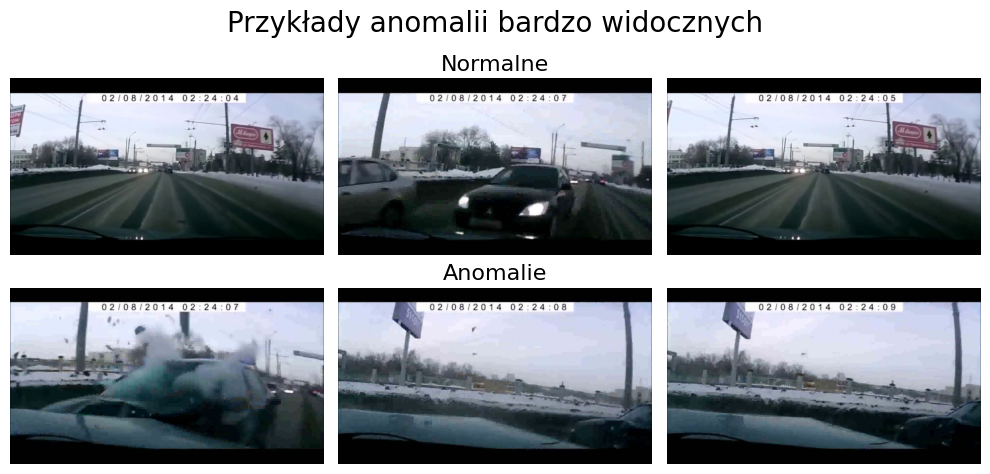

In [27]:
idx = randint(0, len(vid_labels))
titles = ["Normalne", "Anomalie"]

video = images_paths[1][idx]
targets = vid_labels[idx]

fig, axs = plt.subplots(2, 3, figsize=(10, 5))

for i in range(2):
    indices = choices(np.where(targets == i)[0], k=3)
    for j, idx in enumerate(indices):
        image = cv2.cvtColor(cv2.imread(video[idx]), cv2.COLOR_BGR2RGB)
        axs[i, j].imshow(image)
        axs[i, j].axis('off')
        if j == 1:
            axs[i, j].set_title(titles[i], fontsize=16)

fig.suptitle("Przykłady anomalii bardzo widocznych", fontsize=20)
plt.tight_layout()

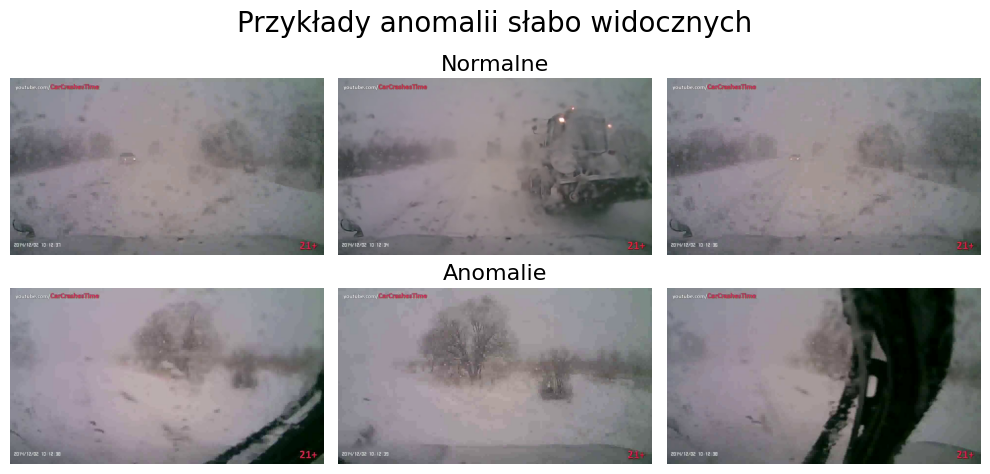

In [28]:
idx = randint(0, len(vid_labels))
titles = ["Normalne", "Anomalie"]

video = images_paths[1][idx]
targets = vid_labels[idx]

fig, axs = plt.subplots(2, 3, figsize=(10, 5))

for i in range(2):
    indices = choices(np.where(targets == i)[0], k=3)
    for j, idx in enumerate(indices):
        image = cv2.cvtColor(cv2.imread(video[idx]), cv2.COLOR_BGR2RGB)
        axs[i, j].imshow(image)
        axs[i, j].axis('off')
        if j == 1:
            axs[i, j].set_title(titles[i], fontsize=16)

fig.suptitle("Przykłady anomalii słabo widocznych", fontsize=20)
plt.tight_layout()

### Colors

<a href="back">Go back</a>

  0%|          | 0/2790 [00:00<?, ?it/s]

  0%|          | 0/2790 [00:00<?, ?it/s]

  0%|          | 0/2790 [00:00<?, ?it/s]

  0%|          | 0/2790 [00:00<?, ?it/s]

  0%|          | 0/2789 [00:00<?, ?it/s]

...

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/960 [00:00<?, ?it/s]

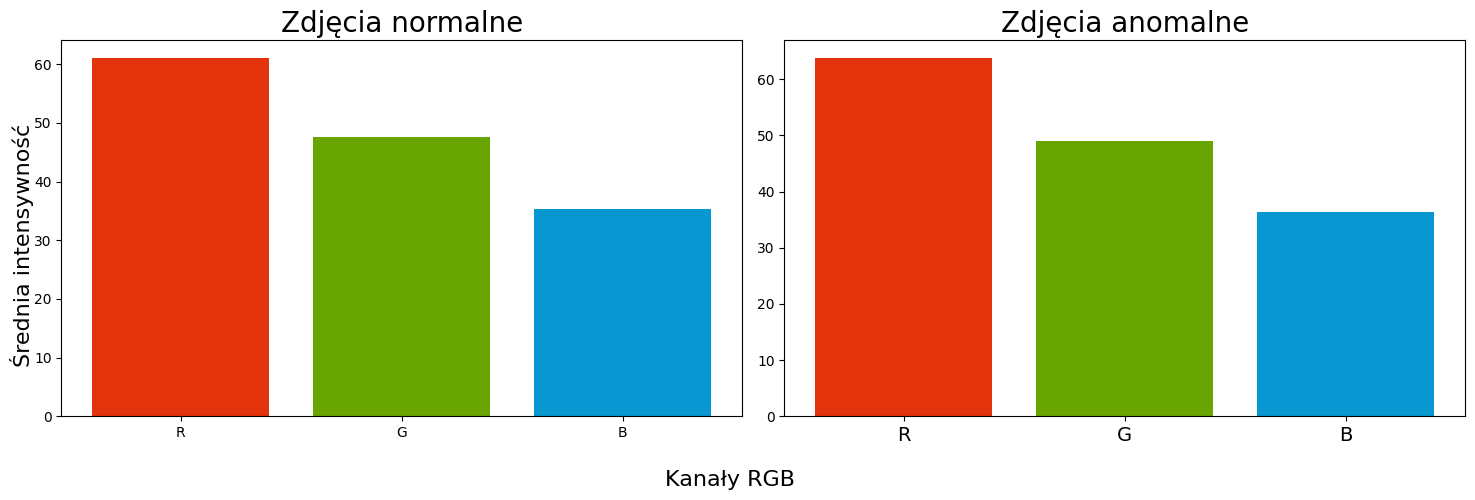

In [36]:
import torch
import numpy as np
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor
import os
import matplotlib.pyplot as plt
import seaborn as sns

normal_indices = torch.where(torch.tensor(vid_labels) == 0)[0]
anomaly_indices = torch.where(torch.tensor(vid_labels) != 0)[0]

imgs = []
for i in range(len(images_paths[0])):
    for j in range(len(images_paths[0][i])):
        imgs.append(images_paths[0][i][j])

w, h = cv2.imread(str(imgs[0])).shape[:2]

def calculate_mean(indices, dataset, desc=None):
    mean = torch.zeros(3, w, h)
    for i in tqdm(indices, desc=desc, leave=False):
        img = cv2.cvtColor(cv2.imread(str(imgs[i])), cv2.COLOR_BGR2RGB).reshape(3, w, h)
        mean += img
    return mean

# Podziel indeksy na mniejsze partie
def split_indices(indices, n_chunks=os.cpu_count()):
    return np.array_split(indices, n_chunks)

# Zrównoleglone obliczenia
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    # Podziel indeksy na partie
    normal_chunks = split_indices(normal_indices)
    anomaly_chunks = split_indices(anomaly_indices)
    
    # Oblicz średnie dla każdej partii
    normal_means = list(executor.map(lambda chunk: calculate_mean(chunk, []), normal_chunks))
    anomaly_means = list(executor.map(lambda chunk: calculate_mean(chunk, images_paths[1]), anomaly_chunks))

# Zsumuj wyniki
mean_normal = sum(normal_means) / len(normal_indices)
mean_anomaly = sum(anomaly_means) / len(anomaly_indices)

mean_normal_r = mean_normal[0].mean()
mean_normal_g = mean_normal[1].mean()
mean_normal_b = mean_normal[2].mean()

mean_anomaly_r = mean_anomaly[0].mean()
mean_anomaly_g = mean_anomaly[1].mean()
mean_anomaly_b = mean_anomaly[2].mean()

# Ustawienie palety kolorów
sns.set_palette("husl")

# Kolory HEX dla lepszego wyglądu
colors_normal = ["#e3330d", "#69a501", "#0997d1"]
colors_anomaly = ["#e3330d", "#69a501", "#0997d1"]

# Tworzenie wykresów z nowymi kolorami
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].bar(range(3), [mean_normal_r, mean_normal_g, mean_normal_b], color=colors_normal)
axs[0].set_title("Zdjęcia normalne", fontsize=20)
axs[0].set_xticks(range(3), ["R", "G", "B"])

axs[1].bar(range(3), [mean_anomaly_r, mean_anomaly_g, mean_anomaly_b], color=colors_anomaly)
axs[1].set_title("Zdjęcia anomalne", fontsize=20)
axs[1].set_xticks(range(3), ["R", "G", "B"], fontsize=14)

fig.supxlabel("Kanały RGB", fontsize=16)
fig.supylabel("Średnia intensywność", fontsize=16)

plt.tight_layout()
plt.show()

### Histogram RGB

  0%|          | 0/2790 [00:00<?, ?it/s]

  0%|          | 0/2790 [00:00<?, ?it/s]

  0%|          | 0/2789 [00:00<?, ?it/s]

  0%|          | 0/2789 [00:00<?, ?it/s]

  0%|          | 0/2789 [00:00<?, ?it/s]

...

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/960 [00:00<?, ?it/s]

  0%|          | 0/961 [00:00<?, ?it/s]

  0%|          | 0/961 [00:00<?, ?it/s]

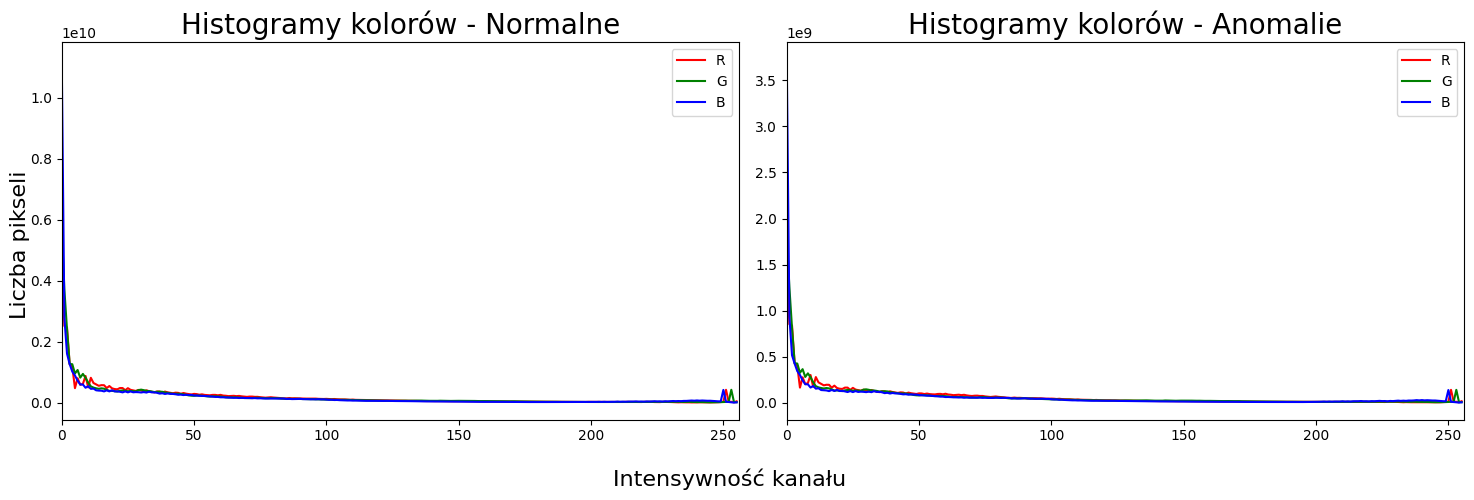

In [40]:
from concurrent.futures import ThreadPoolExecutor
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
from tqdm.notebook import tqdm

normal_indices = torch.where(torch.tensor(vid_labels) == 0)[0]
anomaly_indices = torch.where(torch.tensor(vid_labels) != 0)[0]

imgs = []
for i in range(len(images_paths[0])):
    for j in range(len(images_paths[0][i])):
        imgs.append(images_paths[0][i][j])


def calculate_histograms(indices, dataset, desc=None):
    hist_r = torch.zeros(256)
    hist_g = torch.zeros(256)
    hist_b = torch.zeros(256)
    for i in tqdm(indices, desc=desc, leave=False):
        image_np = cv2.imread(str(dataset[i]))
        
        if image_np is None:
            print(f"Warning: Could not read image at path: {dataset[i]}")
            continue

        image_rgb = cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB)
        img = torch.from_numpy(image_rgb).float() 
        img = img.permute(2, 0, 1)

        hist_r += torch.histc(img[0], bins=256, min=0, max=255)
        hist_g += torch.histc(img[1], bins=256, min=0, max=255)
        hist_b += torch.histc(img[2], bins=256, min=0, max=255)
        
    return hist_r, hist_g, hist_b

# Podziel indeksy na mniejsze partie
def split_indices(indices, n_chunks=os.cpu_count()):
    return np.array_split(indices, n_chunks)

# Zrównoleglone obliczenia
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    # Podziel indeksy na partie
    normal_chunks = split_indices(normal_indices)
    anomaly_chunks = split_indices(anomaly_indices)
    
    # Oblicz średnie dla każdej partii
    normal_results = list(executor.map(lambda chunk: calculate_histograms(chunk, imgs), normal_chunks))
    anomaly_results = list(executor.map(lambda chunk: calculate_histograms(chunk, imgs), anomaly_chunks))

normal_hist_r = torch.zeros(256)
normal_hist_g = torch.zeros(256)
normal_hist_b = torch.zeros(256)

anomaly_hist_r = torch.zeros(256)
anomaly_hist_g = torch.zeros(256)
anomaly_hist_b = torch.zeros(256)

for r, g, b in normal_results:
    normal_hist_r += r
    normal_hist_g += g
    normal_hist_b += b

for r, g, b in anomaly_results:
    anomaly_hist_r += r
    anomaly_hist_g += g
    anomaly_hist_b += b

# Wizualizacja histogramów
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Wykres dla obrazów normalnych
axs[0].plot(range(256), normal_hist_r.numpy(), color='red', label='R')
axs[0].plot(range(256), normal_hist_g.numpy(), color='green', label='G')
axs[0].plot(range(256), normal_hist_b.numpy(), color='blue', label='B')
axs[0].set_title('Histogramy kolorów - Normalne', fontsize=20)
axs[0].set_xlim([0, 256])
axs[0].legend()

# Wykres dla anomalii
axs[1].plot(range(256), anomaly_hist_r.numpy(), color='red', label='R')
axs[1].plot(range(256), anomaly_hist_g.numpy(), color='green', label='G')
axs[1].plot(range(256), anomaly_hist_b.numpy(), color='blue', label='B')
axs[1].set_title('Histogramy kolorów - Anomalie', fontsize=20)
axs[1].set_xlim([0, 256])
axs[1].legend()

fig.supxlabel("Intensywność kanału", fontsize=16)
fig.supylabel("Liczba pikseli", fontsize=16)

plt.tight_layout()
plt.show()